<a href="https://www.kaggle.com/code/lalit7881/predicting-smartphone-addiction-xgb?scriptVersionId=342086656" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e8/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e8/train.csv
/kaggle/input/competitions/playground-series-s6e8/test.csv


## Import libraries

In [2]:
import warnings; warnings.filterwarnings("ignore")
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt


## Import dataset

In [3]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e8/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e8/test.csv")

In [4]:
TARGET = "addicted_label"
FEATURES = [c for c in test.columns if c != "id"]
CAT_COLS = [c for c in FEATURES if train[c].dtype == object]


In [5]:
y = train[TARGET].values
print(train.shape, test.shape, "| base rate:", round(y.mean(), 4))

(691369, 14) (296302, 13) | base rate: 0.7094


In [6]:
both = pd.concat([train[FEATURES], test[FEATURES]], ignore_index=True)

BUDGET_COLS = ["social_media_hours", "gaming_hours", "work_study_hours"]
both["budget_slack"] = both["daily_screen_time_hours"] - both[BUDGET_COLS].sum(axis=1)
both["n_missing"] = both[FEATURES].isna().sum(axis=1)

for c in FEATURES:
    both[f"freq_{c}"] = both[c].map(both[c].value_counts())

ENGINEERED = ["budget_slack", "n_missing"] + [f"freq_{c}" for c in FEATURES]

In [7]:
for c in CAT_COLS:
    both[c] = both[c].astype("category")

train_fe = both.iloc[:len(train)].reset_index(drop=True)
test_fe = both.iloc[len(train):].reset_index(drop=True)
train_fe.shape, test_fe.shape

((691369, 26), (296302, 26))

#### Fold-safe target encoding

In [8]:
def target_encode(train_col, y_train, valid_col, prior_strength=20):
    train_col = train_col.astype(object)
    valid_col = valid_col.astype(object)
    global_mean = y_train.mean()
    stats = pd.DataFrame({"val": train_col, "y": y_train}).groupby("val")["y"].agg(["mean", "count"])
    smoothed = (stats["mean"] * stats["count"] + global_mean * prior_strength) / (stats["count"] + prior_strength)
    return valid_col.map(smoothed).fillna(global_mean).astype(float)

#### Train three models per fold

In [9]:

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

import lightgbm as lgb
import xgboost as xgb

In [10]:
N_FOLDS = 5
folds = StratifiedKFold(N_FOLDS, shuffle=True, random_state=42)

# oof = {"lgb": np.zeros(len(train_fe)), "xgb": np.zeros(len(train_fe)), "cat": np.zeros(len(train_fe))}
# test_pred = {"lgb": np.zeros(len(test_fe)), "xgb": np.zeros(len(test_fe)), "cat": np.zeros(len(test_fe))}
oof = {"lgb": np.zeros(len(train_fe)), "xgb": np.zeros(len(train_fe))}
test_pred = {"lgb": np.zeros(len(test_fe)), "xgb": np.zeros(len(test_fe))}

for fold, (trn_idx, val_idx) in enumerate(folds.split(train_fe, y)):
    X_trn, X_val = train_fe.iloc[trn_idx].copy(), train_fe.iloc[val_idx].copy()
    X_test = test_fe.copy()
    y_trn, y_val = y[trn_idx], y[val_idx]

    for c in FEATURES:
        X_val[f"te_{c}"] = target_encode(X_trn[c], y_trn, X_val[c])
        X_test[f"te_{c}"] = target_encode(X_trn[c], y_trn, X_test[c])
        X_trn[f"te_{c}"] = target_encode(X_trn[c], y_trn, X_trn[c])

    te_cols = [f"te_{c}" for c in FEATURES]
    shared_cols = ENGINEERED + te_cols    
    cat_extra_cols = shared_cols + CAT_COLS    

    # LightGBM 
    lgb_model = lgb.LGBMClassifier(
        n_estimators=1000, learning_rate=0.03, num_leaves=63,
        subsample=0.8, colsample_bytree=0.8, min_child_samples=50,
        random_state=fold, verbosity=-1,)
    lgb_model.fit(X_trn[shared_cols], y_trn, eval_set=[(X_val[shared_cols], y_val)],
                  callbacks=[lgb.early_stopping(40, verbose=False)])
    oof["lgb"][val_idx] = lgb_model.predict_proba(X_val[shared_cols])[:, 1]
    test_pred["lgb"] += lgb_model.predict_proba(X_test[shared_cols])[:, 1] / N_FOLDS

    # XGBoost
    xgb_model = xgb.XGBClassifier(
        n_estimators=1000, learning_rate=0.03, max_depth=7,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
        tree_method="hist", eval_metric="auc",
        early_stopping_rounds=40, random_state=fold, verbosity=0,)
    xgb_model.fit(X_trn[shared_cols], y_trn, eval_set=[(X_val[shared_cols], y_val)], verbose=False)
    oof["xgb"][val_idx] = xgb_model.predict_proba(X_val[shared_cols])[:, 1]
    test_pred["xgb"] += xgb_model.predict_proba(X_test[shared_cols])[:, 1] / N_FOLDS

for name, pred in oof.items():
    print(f"{name} OOF AUC: {roc_auc_score(y, pred):.5f}")

lgb OOF AUC: 0.96468
xgb OOF AUC: 0.96487


#### Blend 

In [11]:
oof_df = pd.DataFrame(oof)
blend_oof = oof_df.mean(axis=1)

print("correlation between models' OOF predictions:")
print(oof_df.corr().round(4))
print()

correlation between models' OOF predictions:
        lgb     xgb
lgb  1.0000  0.9979
xgb  0.9979  1.0000



In [12]:
print(f"blend OOF AUC: {roc_auc_score(y, blend_oof):.5f}")

blend OOF AUC: 0.96493


In [13]:
scores = {name: roc_auc_score(y, pred) for name, pred in oof.items()}
scores["blend"] = roc_auc_score(y, blend_oof)

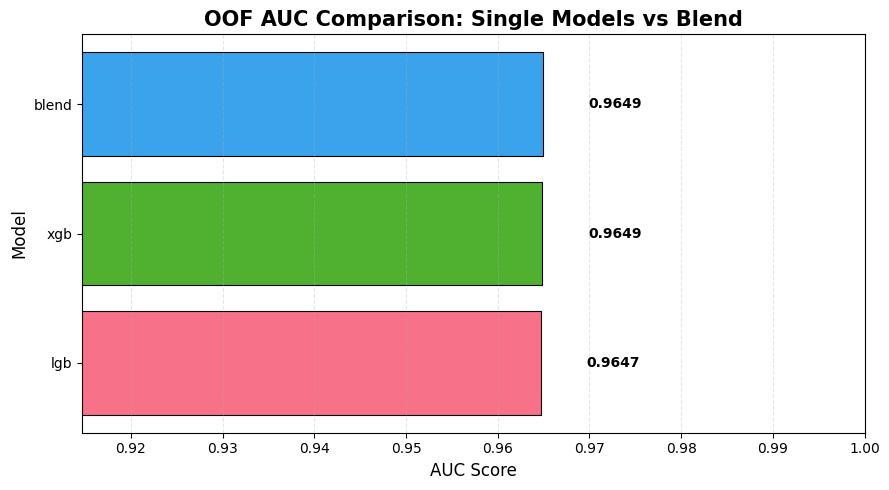

In [14]:
# Sort scores
score_series = pd.Series(scores).sort_values()

# Different color for each model
colors = sns.color_palette("husl", len(score_series))

plt.figure(figsize=(9, 5))

bars = plt.barh(
    score_series.index,
    score_series.values,
    color=colors,
    edgecolor="black",
    linewidth=0.8
)

# Add AUC values on bars
for bar, value in zip(bars, score_series.values):
    plt.text(
        value + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.4f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "OOF AUC Comparison: Single Models vs Blend",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("AUC Score", fontsize=12)
plt.ylabel("Model", fontsize=12)

plt.xlim(
    max(0, score_series.min() - 0.05),
    min(1, score_series.max() + 0.08)
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## Submission

In [15]:
test_blend = (test_pred["lgb"] + test_pred["xgb"]) / 2

submission = pd.DataFrame({"id": test["id"], TARGET: test_blend})
submission.to_csv("submission.csv", index=False)
submission.head()

,id,addicted_label
0,691369,0.999462
1,691370,0.973376
2,691371,0.830279
3,691372,0.990979
4,691373,0.998649


## Thnak you..pls upvote!!!!!!!!!